In [1]:
from matplotlib.backends.backend_pdf import PdfPages
import sys
import numpy as np
import matplotlib.pyplot as plt


from constants import LHAPDF_XGRID, XGRID
import lhapdf

from distance_def import *

In [2]:
flavour = {
    1: "d",
    -1: r"$\bar{d}$",
    2: "u",
    -2: r"$\bar{u}$",
    3: "s",
    -3: r"$\bar{s}$",
    4: "c",
    -4: r"$\bar{c}$",
    5: "b",
    -5: "bbar",
    6: "t",
    21: "g"
}

# Set Q scale
Q = 1.65

# Choose only gluon
flavours = [21]

# Define the x grid of interest
x_grid = LHAPDF_XGRID[74:-47] # points that are >= 0.05 <= 0.6

In [3]:
!vp-get pdf CT18NNLO
!vp-get pdf NNPDF31_nnlo_as_0118
!vp-get pdf NNPDF40_nnlo_as_01180
!vp-get pdf MSHT20nnlo_as118
!vp-get pdf 250503_pod_basis_40k

PDF(name='CT18NNLO', boundary=None)
PDF(name='NNPDF31_nnlo_as_0118', boundary=None)
PDF(name='NNPDF40_nnlo_as_01180', boundary=None)
PDF(name='MSHT20nnlo_as118', boundary=None)
PDF(name='250503_pod_basis_40k', boundary=None)


# Load POD basis

In [4]:
# Take only first 5 elements
basis_dim = 5
pdf_basis = "250503_pod_basis_40k"

wmin_tot_basis = []
center_pdf = lhapdf.mkPDF(pdf_basis, 0)
center_pdf_grid = pdf_grid_allflav(center_pdf, flavours, x_grid, Q)

for i in range(basis_dim):
    wmin_tot_basis.append(lhapdf.mkPDF(pdf_basis, i+1))

LHAPDF 6.5.5 loading /Users/luca/miniforge3/envs/pdf4sbi/share/LHAPDF/250503_pod_basis_40k/250503_pod_basis_40k_0000.dat
250503_pod_basis_40k PDF set, member #0, version 1
LHAPDF 6.5.5 loading /Users/luca/miniforge3/envs/pdf4sbi/share/LHAPDF/250503_pod_basis_40k/250503_pod_basis_40k_0001.dat
250503_pod_basis_40k PDF set, member #1, version 1; LHAPDF ID = 1
LHAPDF 6.5.5 loading /Users/luca/miniforge3/envs/pdf4sbi/share/LHAPDF/250503_pod_basis_40k/250503_pod_basis_40k_0002.dat
250503_pod_basis_40k PDF set, member #2, version 1; LHAPDF ID = 2
LHAPDF 6.5.5 loading /Users/luca/miniforge3/envs/pdf4sbi/share/LHAPDF/250503_pod_basis_40k/250503_pod_basis_40k_0003.dat
250503_pod_basis_40k PDF set, member #3, version 1; LHAPDF ID = 3
LHAPDF 6.5.5 loading /Users/luca/miniforge3/envs/pdf4sbi/share/LHAPDF/250503_pod_basis_40k/250503_pod_basis_40k_0004.dat
250503_pod_basis_40k PDF set, member #4, version 1; LHAPDF ID = 4
LHAPDF 6.5.5 loading /Users/luca/miniforge3/envs/pdf4sbi/share/LHAPDF/250503_pod

In [5]:
# Example of how to call the PDF with LHAPDF api

# gluon (21), x = 0.5, at scale Q
center_pdf.xfxQ(21, 0.5, Q)

0.1742692129569472

## Define the POD PDF

In [6]:
class POD_PDF():
    def __init__(self, central_pdf, modes):
        self.central_pdf = central_pdf
        self.modes = modes

    def __call__(self, fl, x, Q, weights):
        phi0 = self.central_pdf.xfxQ(fl, x, Q)
        phis = [mode.xfxQ(fl, x, Q) for mode in self.modes]
        
        for i, w in enumerate(weights):
            phis[i] = w * (phis[i] - phi0)

        return phi0 + sum(phis)

In [7]:
# example of building and calling it
pod_pdf = POD_PDF(center_pdf, wmin_tot_basis)

weights = [0.1, 0.2, 0.3, -0.1, -0.2]

pod_pdf(21, 0.5, Q, weights)

17.31253504978912

# Test flexibility against PDF sets

In [8]:
# Here we define the PDFs we want to try to reproduce
PDF_sets = {
    "CT18NNLO": 58,
    "NNPDF31_nnlo_as_0118": 100,
    "NNPDF40_nnlo_as_01180": 100,
    "MSHT20nnlo_as118": 64,
}

pdfs_target = {}

for PDF_set, nreps in PDF_sets.items():
    pdfs_target[PDF_set] = []

    for i in range(nreps):
        pdfs_target[PDF_set].append(lhapdf.mkPDF(PDF_set, i+1))

LHAPDF 6.5.5 loading /Users/luca/miniforge3/envs/pdf4sbi/share/LHAPDF/CT18NNLO/CT18NNLO_0001.dat
CT18NNLO PDF set, member #1, version 1; LHAPDF ID = 14001
LHAPDF 6.5.5 loading /Users/luca/miniforge3/envs/pdf4sbi/share/LHAPDF/CT18NNLO/CT18NNLO_0002.dat
CT18NNLO PDF set, member #2, version 1; LHAPDF ID = 14002
LHAPDF 6.5.5 loading /Users/luca/miniforge3/envs/pdf4sbi/share/LHAPDF/CT18NNLO/CT18NNLO_0003.dat
CT18NNLO PDF set, member #3, version 1; LHAPDF ID = 14003
LHAPDF 6.5.5 loading /Users/luca/miniforge3/envs/pdf4sbi/share/LHAPDF/CT18NNLO/CT18NNLO_0004.dat
CT18NNLO PDF set, member #4, version 1; LHAPDF ID = 14004
LHAPDF 6.5.5 loading /Users/luca/miniforge3/envs/pdf4sbi/share/LHAPDF/CT18NNLO/CT18NNLO_0005.dat
CT18NNLO PDF set, member #5, version 1; LHAPDF ID = 14005
LHAPDF 6.5.5 loading /Users/luca/miniforge3/envs/pdf4sbi/share/LHAPDF/CT18NNLO/CT18NNLO_0006.dat
CT18NNLO PDF set, member #6, version 1; LHAPDF ID = 14006
LHAPDF 6.5.5 loading /Users/luca/miniforge3/envs/pdf4sbi/share/LHAPDF/

In [9]:
distances = {}
summed_distances = {}
mean_squared_error = {}
median_squared_error = {}

basis_dims = [1, 3, 5]

for pdf_target_name, pdf_target_replicas in pdfs_target.items():
    
    distances[pdf_target_name] = []
    summed_distances[pdf_target_name] = []
    mean_squared_error[pdf_target_name] = []
    median_squared_error[pdf_target_name] = []

    for basis_dim in basis_dims:
        wmin_basis = wmin_tot_basis[:basis_dim]
        
        distance = []

        for pdf_target_replica in pdf_target_replicas:
            original, reco, w, d = wmin_distance(pdf_target_replica, center_pdf_grid, wmin_basis, flavours, x_grid, Q, dist_type=0)
            distance.append(d)

        distances[pdf_target_name].append((basis_dim, distance))
        summed_distances[pdf_target_name].append(np.sum(distance))
        mean_squared_error[pdf_target_name].append(np.mean(distance))
        median_squared_error[pdf_target_name].append(np.median(distance))

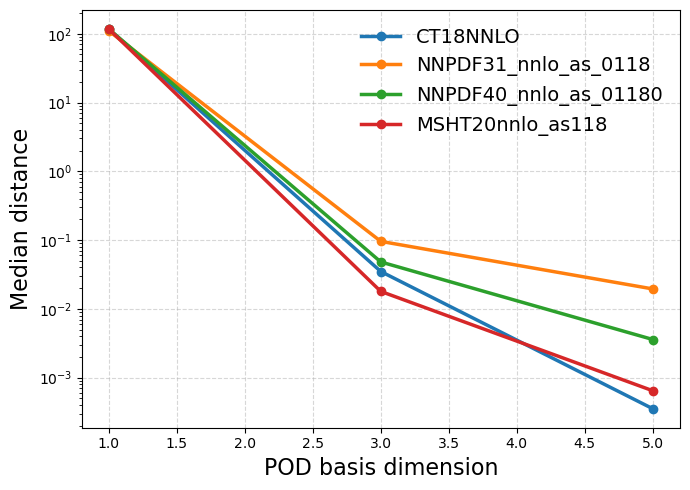

In [10]:
fig, ax = plt.subplots(figsize=(7, 5))

for pdf_target_name, pdf_target_replicas in pdfs_target.items():
    ax.plot(basis_dims, median_squared_error[pdf_target_name], "-o", label=f"{pdf_target_name}", linewidth=2.5)
    

# Labels and legend 
ax.set_xlabel("POD basis dimension", fontsize=16)
ax.set_ylabel("Median distance", fontsize=16)
ax.legend(frameon=False, fontsize=14, loc="upper right")

# Improve grid visibility
ax.grid(True, linestyle="--", alpha=0.5)
ax.set_yscale("log")
# Adjust layout and save
plt.tight_layout()
fig.savefig("median_distance_generalisation.pdf",  bbox_inches='tight', dpi=300)
plt.show()

# Plot PDF vs reconstructed

In [12]:
pdf_target = "MSHT20nnlo_as118"
with PdfPages(f"{pdf_target}.pdf") as pdf:
    for j in range(50):
        original, reco, w, d = wmin_distance(
            pdfs_target[pdf_target][j], center_pdf_grid, wmin_tot_basis[:basis_dim], flavours, x_grid, Q, dist_type=0
        )
    
        EPSILON = 1e-4
        for i in range(len(flavours)):
    
            fig, [axup, axdown] = plt.subplots(
                2, 1, sharex=True, figsize=(7, 7), gridspec_kw={"height_ratios": [3, 1], "hspace": 0.05}
            )
            
            # Upper plot: original vs reconstructed PDF
            axup.plot(x_grid, original[i], label="Original", linewidth=4)
            axup.plot(x_grid, reco[i], label="Reconstructed", linewidth=3, linestyle="dashed")
    
            # Lower plot: Ratio plot
            axdown.plot(x_grid, reco[i] / (original[i]+EPSILON), linewidth=3)
            axdown.axhline(1.0, color="gray", linestyle="--", linewidth=1.5, alpha=0.7)  # Reference line
            axdown.set_ylim(0.5, 1.5)  # Adjust for better readability
            axdown.set_xlabel("x", fontsize=16)
            axdown.set_ylabel("Ratio", fontsize=16)
    
            # Formatting upper plot
            axup.set_title(f"{flavour[flavours[i]]}(x) PDF {pdf_target} rep {j}", fontsize=16)
            axup.set_xscale("log")
            axup.set_ylabel(r"$x f(x)$", fontsize=16)
            axup.legend(frameon=False, fontsize=14)
    
            # Improve grid visibility
            axup.grid(True, linestyle="--", alpha=0.5)
            axdown.grid(True, linestyle="--", alpha=0.5)
    
            # Save and close
            pdf.savefig(bbox_inches="tight")
            plt.close()

In [11]:
pdf_target = "NNPDF31_nnlo_as_0118"
with PdfPages(f"{pdf_target}.pdf") as pdf:
    for j in range(50):
        original, reco, w, d = wmin_distance(
            pdfs_target[pdf_target][j], center_pdf_grid, wmin_tot_basis[:basis_dim], flavours, x_grid, Q, dist_type=0
        )
    
        EPSILON = 1e-4
        for i in range(len(flavours)):
    
            fig, [axup, axdown] = plt.subplots(
                2, 1, sharex=True, figsize=(7, 7), gridspec_kw={"height_ratios": [3, 1], "hspace": 0.05}
            )
            
            # Upper plot: original vs reconstructed PDF
            axup.plot(x_grid, original[i], label="Original", linewidth=4)
            axup.plot(x_grid, reco[i], label="Reconstructed", linewidth=3, linestyle="dashed")
    
            # Lower plot: Ratio plot
            axdown.plot(x_grid, reco[i] / (original[i]+EPSILON), linewidth=3)
            axdown.axhline(1.0, color="gray", linestyle="--", linewidth=1.5, alpha=0.7)  # Reference line
            axdown.set_ylim(0.5, 1.5)  # Adjust for better readability
            axdown.set_xlabel("x", fontsize=16)
            axdown.set_ylabel("Ratio", fontsize=16)
    
            # Formatting upper plot
            axup.set_title(f"{flavour[flavours[i]]}(x) PDF {pdf_target} rep {j}", fontsize=16)
            axup.set_xscale("log")
            axup.set_ylabel(r"$x f(x)$", fontsize=16)
            axup.legend(frameon=False, fontsize=14)
    
            # Improve grid visibility
            axup.grid(True, linestyle="--", alpha=0.5)
            axdown.grid(True, linestyle="--", alpha=0.5)
    
            # Save and close
            pdf.savefig(bbox_inches="tight")
            plt.close()